In [96]:
import numpy as np
from percept_parser import percept
import plotly.express as px
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import zscore


In [97]:
filename = "reports/Report_Json_Session_Report_20250410T170729.json"
parser = percept.PerceptParser(filename, True)
dfs_bs_td = parser.read_timedomain_data(False)

reports/Report_Json_Session_Report_20250410T170729.json: 2025-04-10 21:24:55+00:00 - AIC


BrainSenseTimeDomain Index: 100%|██████████| 3/3 [00:03<00:00,  1.26s/it]


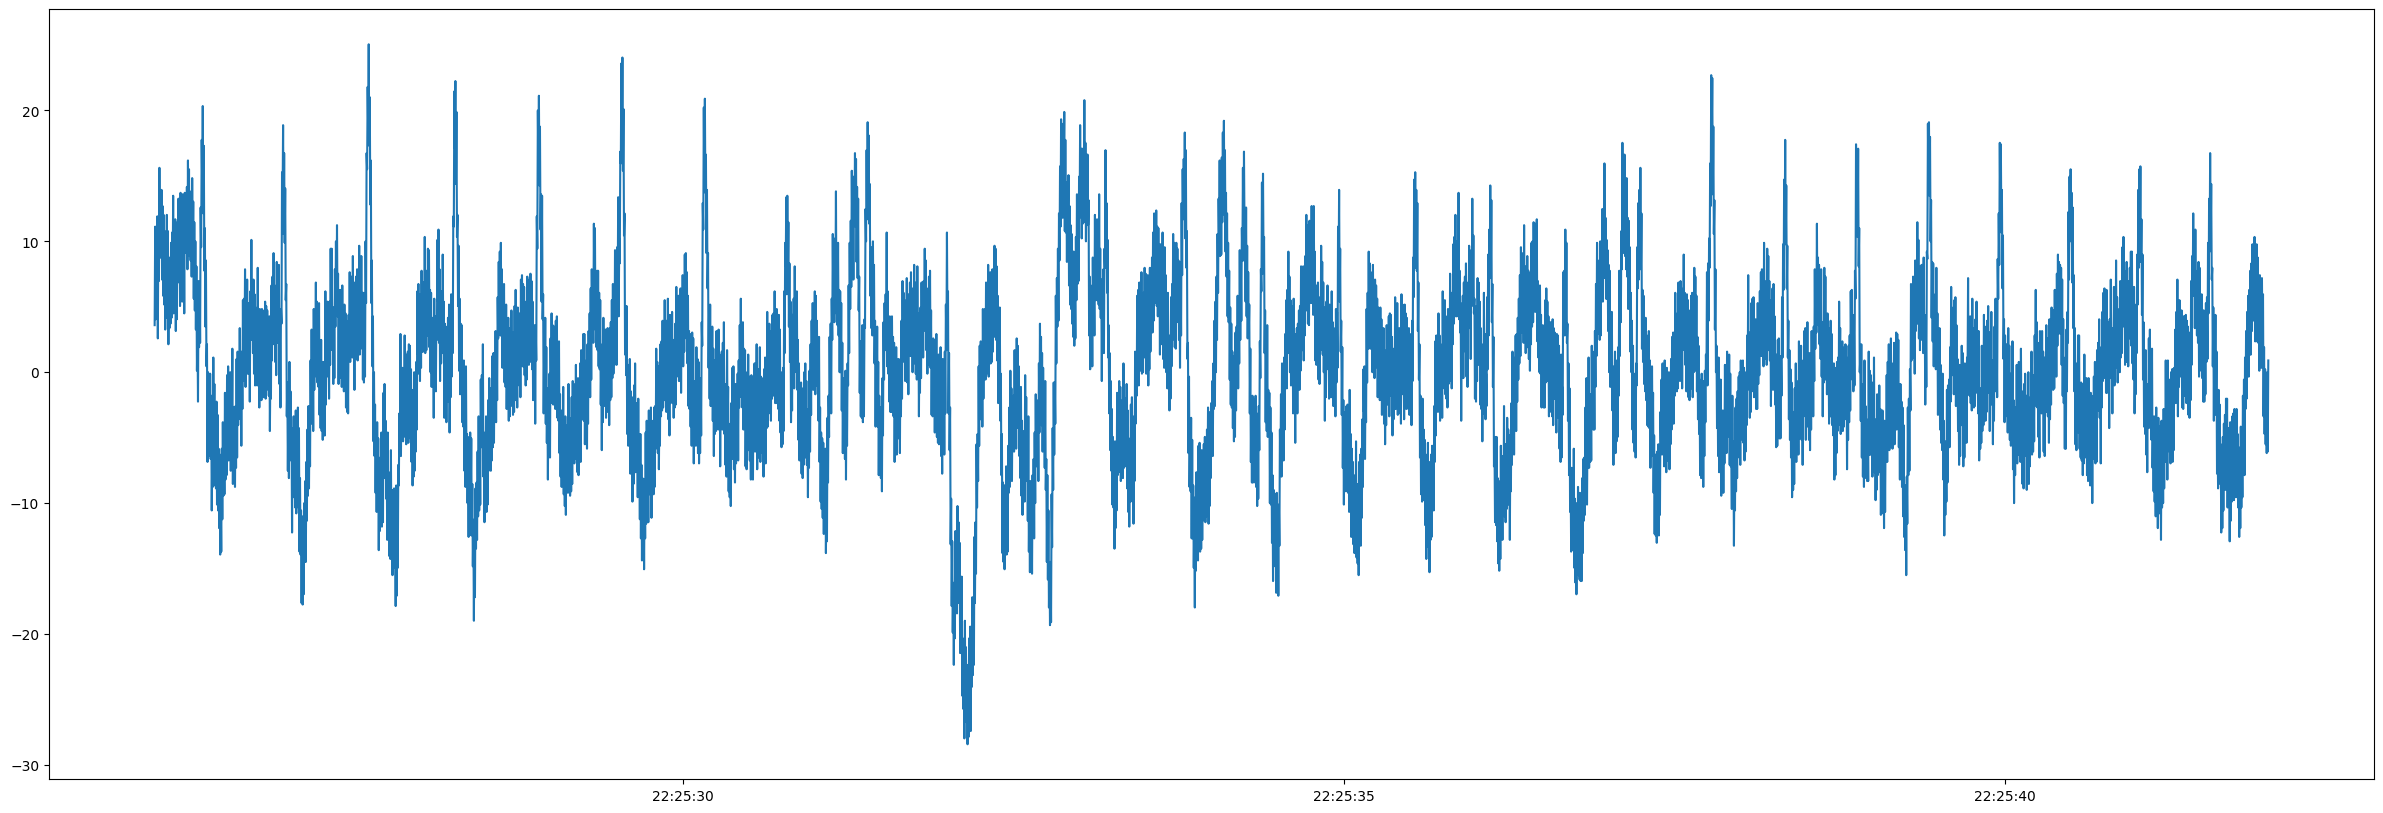

In [98]:
# lfp_signal = dfs_bs_td[1].iloc[:,1][30000:250000]
# lfp_signal_trimmed = dfs_bs_td[1].iloc[:,1][56000:60000]
lfp_signal = dfs_bs_td[1].iloc[:,1][54000:58000]
# for df in dfs_bs_td:
#     print(df.shape[0])

plt.figure(figsize=(30,10))
plt.plot(lfp_signal)



### 1. Step 1: R-peak Detection

   -> Found 20 peaks. Orientation: Positive


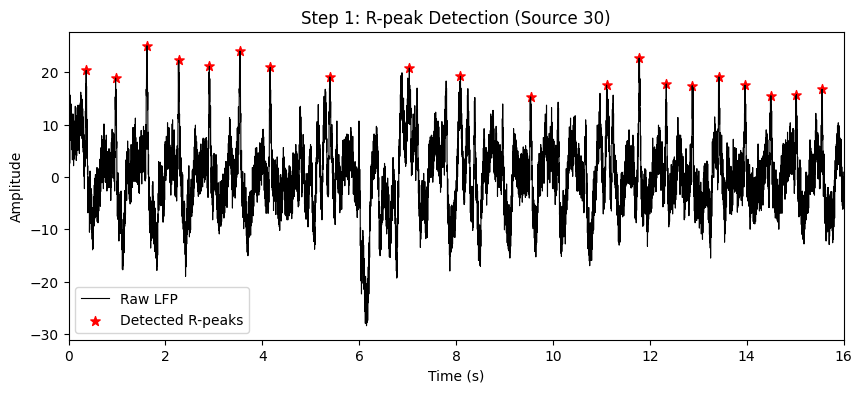

In [99]:
fs = 250
lfp_z = zscore(lfp_signal)

# Thresholds: 2.5 SD height, 500ms distance
min_height = 2  #   2.5 does not detect enough
min_distance = int(0.5 * fs)

# Detect positive and negative peaks [cite: 34]
peaks_pos, props_pos = find_peaks(lfp_z, height=min_height, distance=min_distance)
peaks_neg, props_neg = find_peaks(-lfp_z, height=min_height, distance=min_distance)

# Determine orientation [cite: 35]
mean_amp_pos = np.mean(props_pos["peak_heights"]) if len(peaks_pos) > 0 else 0
mean_amp_neg = np.mean(props_neg["peak_heights"]) if len(peaks_neg) > 0 else 0

if mean_amp_neg > mean_amp_pos and len(peaks_neg) >= len(peaks_pos) * 0.8:
    r_peaks = peaks_neg
    orientation = "Negative"
else:
    r_peaks = peaks_pos
    orientation = "Positive"

print(f"   -> Found {len(r_peaks)} peaks. Orientation: {orientation}")

time_axis = np.arange(len(lfp_signal)) / fs
duration_sec = len(lfp_signal) / fs
# Plot 1: R-peak Detection
plt.figure(figsize=(10, 4))
plt.plot(time_axis, lfp_signal, color="black", linewidth=0.8)
plt.scatter(r_peaks / fs, lfp_signal.to_numpy()[r_peaks], color="red", marker="*", s=50)
plt.title("Step 1: R-peak Detection (Source 30)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, duration_sec)
plt.legend(["Raw LFP", "Detected R-peaks"])
plt.show()

#### Step 2: Template Generation

In [100]:
# Window: 200ms before and after [cite: 44]
win_samples = int(0.2 * fs)

epochs = []
valid_peaks = []

for r in r_peaks:
    start = r - win_samples
    end = r + win_samples
    if start >= 0 and end < len(lfp_signal):
        epochs.append(lfp_signal[start:end])
        valid_peaks.append(r)
        
# if not epochs:
#     return lfp_signal

epochs_arr = np.array(epochs)
# 
raw_template = np.mean(epochs_arr, axis=0) 

# Equalizing Tails (outer 30 samples)
tail_len = 30
if len(raw_template) < 2 * tail_len:
    tail_len = len(raw_template) // 2

t_start_seg = raw_template[:tail_len]
t_end_seg = raw_template[-tail_len:]

min_diff = np.inf
cut_start = 0
cut_end = 0

for i, val_start in enumerate(t_start_seg):
    for j, val_end in enumerate(t_end_seg):
        diff = abs(val_start - val_end)
        if diff < min_diff:
            min_diff = diff
            cut_start = i
            cut_end = (len(raw_template) - tail_len) + j
            
final_template = raw_template[cut_start : cut_end + 1].copy()

# Fix offset (set ends to same value) [cite: 49, 50]
target_val = max(final_template[0], final_template[-1])
final_template[0] = target_val
final_template[-1] = target_val



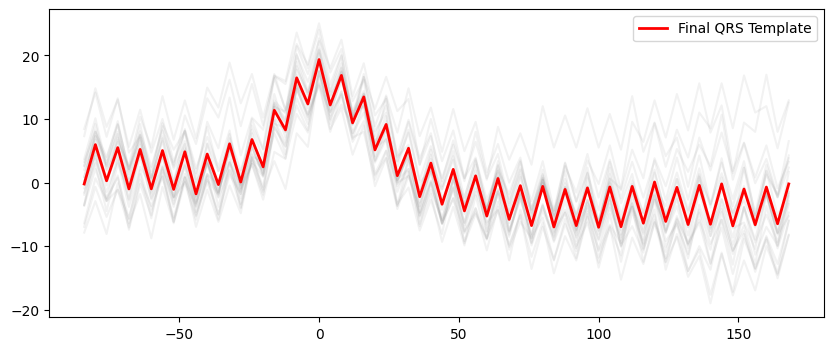

In [101]:
# Plot 2: Template Generation (All epochs vs Template)
# Create time axis for template (centered around 0 for R-peak)
# The template starts at 'template_rel_start' samples relative to R-peak
template_rel_start = -win_samples + cut_start
t_template = np.arange(len(final_template)) + template_rel_start
t_template_ms = (t_template / fs) * 1000

plt.figure(figsize=(10, 4))

# Plot a subset of raw epochs (grey lines)
for ep in epochs: # Limit to 100 for performance
    # We need to trim the raw epoch to match the final template alignment for visual comparison
    # The raw epoch was win_samples*2 long. 
    # The final template corresponds to indices [cut_start : cut_end] of that raw epoch
    if cut_end + 1 <= len(ep):
        ep_trimmed = ep[cut_start : cut_end + 1]
        if len(ep_trimmed) == len(t_template_ms):
            plt.plot(t_template_ms, ep_trimmed, color='grey', alpha=0.1)

plt.plot(t_template_ms, final_template, color='red', linewidth=2, label='Final QRS Template')
# plt.set_title(f'Step 2: Template Generation (Avg of {len(epochs)} epochs) (Source 42)')
# plt.set_xlabel('Time relative to R-peak (ms)')
plt.legend()



### Step 3 & 4: Optimization and Subtraction

In [102]:
lfp_cleaned = lfp_signal.copy()
template_rel_start = -win_samples + cut_start

# Store data for plotting one example epoch
example_plot_data = {}

for i, r in enumerate(valid_peaks):
    seg_start = r + template_rel_start
    seg_end = seg_start + len(final_template)
    
    if seg_start < 0 or seg_end > len(lfp_signal):
        continue
        
    lfp_epoch = lfp_signal[seg_start:seg_end]
    
    # Linear regression to find scale and offset 
    if len(lfp_epoch) == len(final_template):
        scale, offset = np.polyfit(final_template, lfp_epoch, 1)
        artifact_model = (scale * final_template) + offset
        
        # Subtraction
        lfp_cleaned[seg_start:seg_end] = lfp_epoch - artifact_model
        
        # Save the middle-most epoch for visualization
        if i == len(valid_peaks) // 2:
            example_plot_data = {
                'raw': lfp_epoch,
                'fitted': artifact_model,
                'cleaned': lfp_epoch - artifact_model
            }



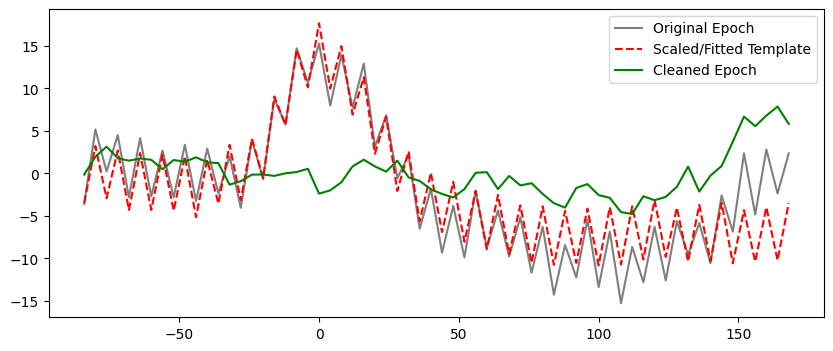

In [103]:
plt.figure(figsize=(10, 4))
plt.plot(t_template_ms, example_plot_data['raw'], 'k-', alpha=0.5, label='Original Epoch')
plt.plot(t_template_ms, example_plot_data['fitted'], 'r--', label='Scaled/Fitted Template')
plt.plot(t_template_ms, example_plot_data['cleaned'], 'g-', linewidth=1.5, label='Cleaned Epoch')
# plt.set_title('Step 3: Template Optimization (Single Epoch Example) (Source 89)')
plt.legend()

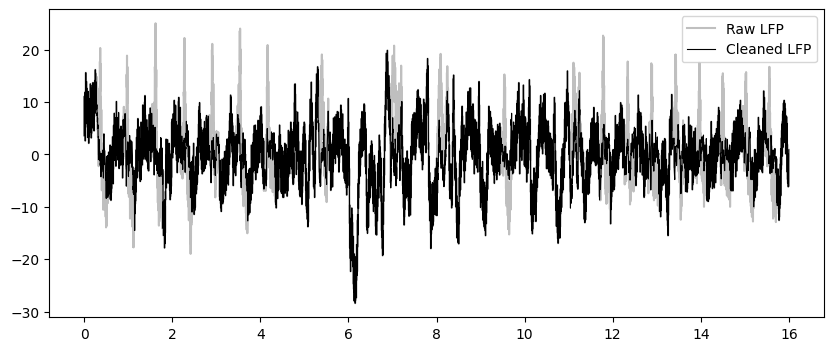

In [104]:
plt.figure(figsize=(10, 4))

plt.plot(time_axis, lfp_signal, color='grey', alpha=0.5, label='Raw LFP ')
plt.plot(time_axis, lfp_cleaned, color='black', linewidth=0.8, label='Cleaned LFP')
# plt.set_title('Step 4: Final Subtraction Result (Source 91)')
# plt.set_xlabel('Time (s)')
# plt.set_xlim(0, min(5, duration_sec)) # Zoom in on first 5 seconds
plt.legend(loc='upper right')
plt.show()


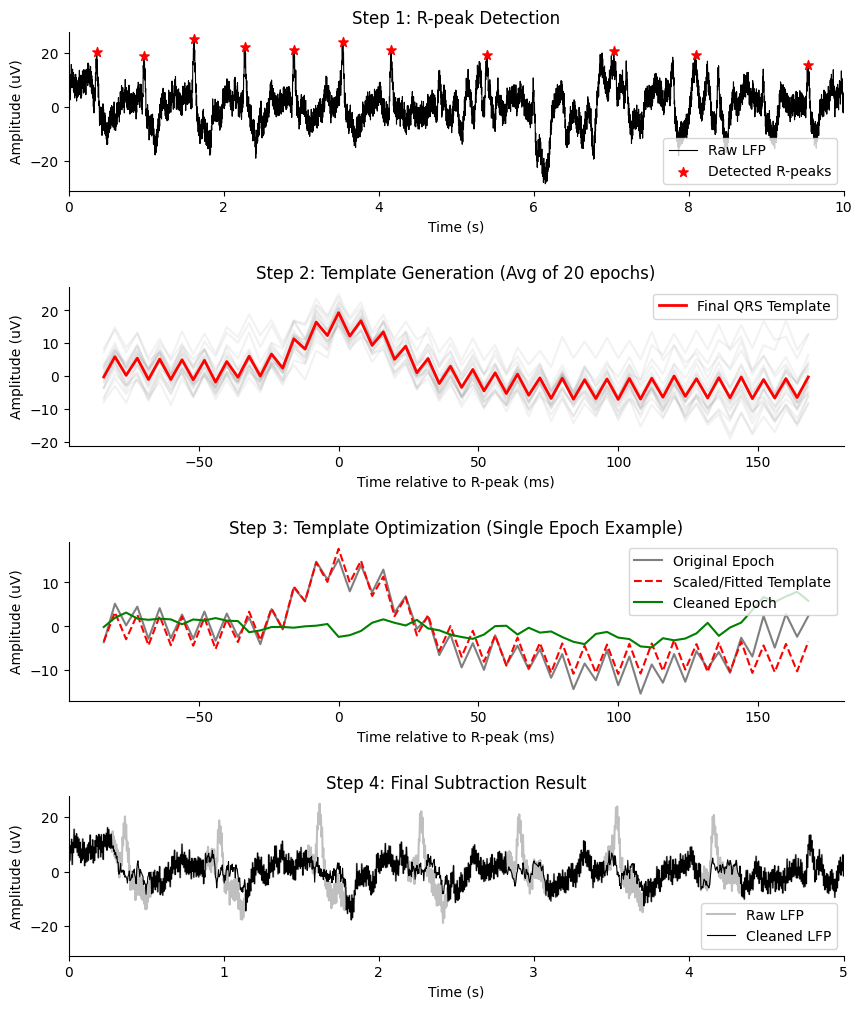

In [108]:
# --- PLOTTING ---
time_axis = np.arange(len(lfp_signal)) / fs

fig, axes = plt.subplots(4, 1, figsize=(10, 12))
fig.subplots_adjust(hspace=0.6)  

# Plot 1: R-peak Detection
axes[0].plot(time_axis, lfp_signal, color='black', linewidth=0.8, label='Raw LFP')
axes[0].scatter(r_peaks / fs, lfp_signal.to_numpy()[r_peaks], color='red', marker='*', s=50, label='Detected R-peaks', zorder=5)
axes[0].set_title('Step 1: R-peak Detection')
axes[0].set_ylabel('Amplitude (uV)')
axes[0].set_xlabel('Time (s)')
axes[0].legend(loc='lower right')
axes[0].set_xlim(0, min(10, duration_sec)) # Show first 10 seconds or full length

# Plot 2: Template Generation (All epochs vs Template)
# Create time axis for template (centered around 0 for R-peak)
# The template starts at 'template_rel_start' samples relative to R-peak
t_template = np.arange(len(final_template)) + template_rel_start
t_template_ms = (t_template / fs) * 1000

# Plot a subset of raw epochs (grey lines)
for ep in epochs: # Limit to 100 for performance
    # We need to trim the raw epoch to match the final template alignment for visual comparison
    # The raw epoch was win_samples*2 long. 
    # The final template corresponds to indices [cut_start : cut_end] of that raw epoch
    if cut_end + 1 <= len(ep):
        ep_trimmed = ep[cut_start : cut_end + 1]
        if len(ep_trimmed) == len(t_template_ms):
            axes[1].plot(t_template_ms, ep_trimmed, color='grey', alpha=0.1)

axes[1].plot(t_template_ms, final_template, color='red', linewidth=2, label='Final QRS Template')
axes[1].set_title(f'Step 2: Template Generation (Avg of {len(epochs)} epochs)')
axes[1].set_ylabel('Amplitude (uV)')
axes[1].set_xlabel('Time relative to R-peak (ms)')
axes[1].legend()

# Plot 3: Template Optimization (Single Epoch Zoom)
if example_plot_data:
    axes[2].plot(t_template_ms, example_plot_data['raw'], 'k-', alpha=0.5, label='Original Epoch')
    axes[2].plot(t_template_ms, example_plot_data['fitted'], 'r--', label='Scaled/Fitted Template')
    axes[2].plot(t_template_ms, example_plot_data['cleaned'], 'g-', linewidth=1.5, label='Cleaned Epoch')
    axes[2].set_title('Step 3: Template Optimization (Single Epoch Example)')
    axes[2].set_ylabel('Amplitude (uV)')
    axes[2].set_xlabel('Time relative to R-peak (ms)') # <--- ADDED AS REQUESTED
    axes[2].legend()

# Plot 4: Final Result (Raw vs Cleaned)
axes[3].plot(time_axis, lfp_signal, color='grey', alpha=0.5, label='Raw LFP')
axes[3].plot(time_axis, lfp_cleaned, color='black', linewidth=0.8, label='Cleaned LFP')
axes[3].set_title('Step 4: Final Subtraction Result')
axes[3].set_ylabel('Amplitude (uV)')
axes[3].set_xlabel('Time (s)')
axes[3].set_xlim(0, min(5, duration_sec)) # Zoom in on first 5 seconds
axes[3].legend(loc='lower right')

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.show()